In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    # library(scater)
    library(Seurat)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [2]:
myeloid <- readRDS('../data/ascites_myeloid_mapped_to_pDG_atlas.rds')
myeloid

An object of class Seurat 
44192 features across 9876 samples within 8 assays 
Active assay: RNA (22492 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 7 other assays present: SCT, prediction.score.dmg.atlas.lvl_1, prediction.score.dmg.atlas.lvl_2, prediction.score.dmg.atlas.lvl_3, prediction.score.dmg.atlas.lvl_4, prediction.score.dmg.atlas.lvl_4_coarse, prediction.score.dmg.atlas.lvl_5
 4 dimensional reductions calculated: mnn, umap, pca, ref.pca

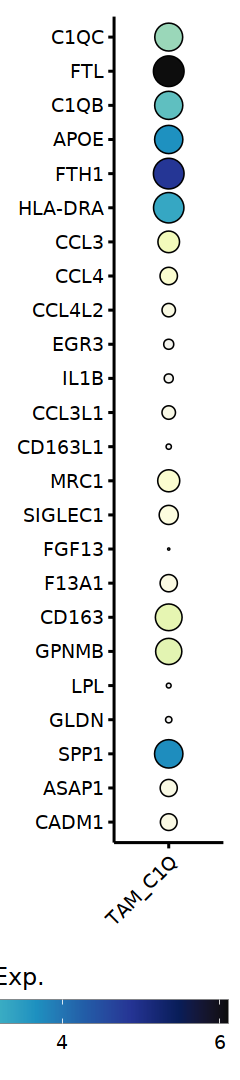

In [11]:
genes <- rev(c('C1QC', 'FTL', 'C1QB', 'APOE', 'FTH1', 'HLA-DRA',
            'CCL3', 'CCL4', 'CCL4L2', 'EGR3', 'IL1B', 'CCL3L1', 'CD163L1', 
            'MRC1', 'SIGLEC1', 'FGF13', 'F13A1', 'CD163',
            'GPNMB', 'LPL', 'GLDN', 'SPP1', 'ASAP1', 'CADM1'))

options(repr.plot.height = 9, repr.plot.width = 2)
SCpubr::do_DotPlot(sample = subset(myeloid, predicted.dmg.atlas.lvl_4_coarse=='TAM_C1Q'),flip = TRUE,
                             group.by = 'predicted.dmg.atlas.lvl_4_coarse',
                             features = genes)

In [12]:
ggsave('../figures/marker_genes_myeloid_mps_ascites.pdf',height = 9, width = 2)

In [2]:
dmg <- readRDS('/hpc/pmc_stunnenberg/cruiz/scRNA/analysis/pmc_patients/dipg_ascitis/deep_sequencing/for_publication/data/ascites/t-cells_dmg_ascites.rds')

In [5]:
dmg.markers <- FindAllMarkers(dmg, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)

Calculating cluster CD8

Calculating cluster CD4

Calculating cluster TCRgd



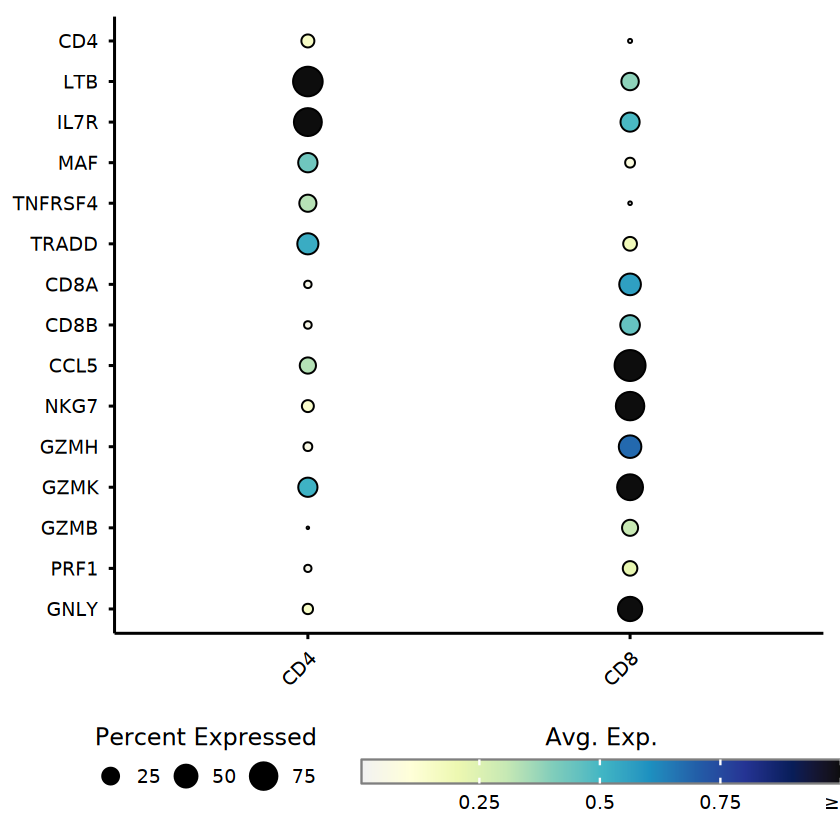

In [7]:
genes <- rev(c(
  "CD4", "LTB", "IL7R", "MAF", "TNFRSF4", "TRADD",
  "CD8A","CD8B","CCL5", "NKG7", "GZMH", "GZMK","GZMB","PRF1", "GNLY"
))

SCpubr::do_DotPlot(subset(dmg, idents=c('CD4','CD8')),
                  genes,
                   max.cutoff=1 ,
                   flip = TRUE
                  )

In [9]:
ggsave('figures/t_cells_ascites_marker_genes.pdf', height = 6, width = 2)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$la